# 03a — Deterministic Individual Simulation

Calculate deterministic lifetime retirement values under High-Three
and BRS for each profile and separation scenario.

**TSP modeling:** Member contributes 5% under both systems.
BRS adds government contributions (1% auto + 4% match = 5% govt),
bringing BRS total to 10%. High-Three total stays at 5%.
The comparison isolates what the government provides differently.

**Fixed assumptions:** TSP returns = glide-path L Fund historical
means; COLA = 2.75% (DoD actuarial); life expectancy = SSA 2022
male expected total age.

**Inputs:** `data/processed/pay_profiles.csv`,
`data/processed/tsp_returns.csv`,
`data/processed/life_expectancy.csv`  
**Output:** `data/processed/deterministic_results.csv`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../src")))
from pension_calcs import (  # noqa: E402
    annual_pension_brs,
    annual_pension_high3,
    high_three_base,
)
from tsp_calcs import (  # noqa: E402
    BRS_CONTRIB_RATE,
    H3_MEMBER_RATE,
    compute_fund_means,
    tsp_at_separation,
    tsp_grow_to_60,
)
from utils import npv_pension, pv_lump_sum  # noqa: E402

PROCESSED = Path("../data/processed")

## Model constants

In [2]:
PROFILES = ["Officer", "Enlisted", "PriorEnlistedOfficer"]
PROFILE_SCENARIOS = {
    "Officer": list(range(4, 39, 2)),
    "Enlisted": list(range(4, 29, 2)),
    "PriorEnlistedOfficer": list(range(4, 39, 2)),
}
ENTRY_AGE = {
    "Officer": 22,
    "Enlisted": 18,
    "PriorEnlistedOfficer": 18,
}

COLA_RATE = 0.0275    # DoD Board of Actuaries long-term
DISCOUNT_RATE = 0.05  # Nominal rate for NPV calculations

print(
    f"BRS contribution rate: {BRS_CONTRIB_RATE:.0%}"
    " (member 5% + govt 5%)"
)
print(
    f"H3  contribution rate: {H3_MEMBER_RATE:.0%}"
    " (member 5% only)"
)


BRS contribution rate: 10% (member 5% + govt 5%)
H3  contribution rate: 5% (member 5% only)


## Load data

In [3]:
pay_profiles = pd.read_csv(PROCESSED / "pay_profiles.csv")
tsp_returns = pd.read_csv(PROCESSED / "tsp_returns.csv")
life_exp = pd.read_csv(PROCESSED / "life_expectancy.csv")

print(f"pay_profiles: {pay_profiles.shape}")
print(f"tsp_returns:  {tsp_returns.shape}")
print(f"life_exp:     {life_exp.shape}")

pay_profiles: (110, 3)
tsp_returns:  (39, 21)
life_exp:     (120, 5)


## TSP glide-path fund means

Historical mean annual return for each L Fund used in the glide path.
These are the fixed returns for the deterministic scenario; notebook
03b will draw from the full return distributions.

**Data note:** L Fund return histories are extended back to 2002 via
synthetic reconstruction — regression weights (SLSQP, constrained to
sum to 1) fit on the overlapping period are applied to the five
underlying individual-fund returns (C, S, I, F, G). Only pre-inception
NaN values are backfilled; actual reported values are unchanged.
R² > 0.99 for all four L Funds. L 2050 gains 10 additional years
(n: 14 → 24), correcting for selection bias from its 2012 inception
missing the 2001–2002 bear market.

In [4]:
means = compute_fund_means(tsp_returns)

print("L Fund mean annual returns (deterministic baseline):")
for fund, r in means.items():
    n = tsp_returns[fund].notna().sum()
    print(f"  {fund:<12} {r:.2%}  (n={n} years)")

L Fund mean annual returns (deterministic baseline):
  L 2050       9.47%  (n=24 years)
  L 2040       8.93%  (n=24 years)
  L 2030       8.09%  (n=24 years)
  L Income     4.80%  (n=24 years)


## Officer, 20 YOS — step-by-step walkthrough

Both systems credit the member's own 5% TSP contribution.
The difference between systems comes only from the govt's 5%
addition (BRS only) and the pension multiplier difference.

In [5]:
DEMO_PROFILE = "Officer"
DEMO_YOS = 20
sep_age = ENTRY_AGE[DEMO_PROFILE] + DEMO_YOS

pay = pay_profiles.query(
    "Profile == @DEMO_PROFILE and YOS <= @DEMO_YOS"
).set_index("YOS")["MonthlyPay"]

h3_base = high_three_base(pay)

life_row = life_exp.loc[
    life_exp["Age"] == sep_age
].squeeze()
n_pension_yrs = life_row["MaleTotalAge"] - sep_age

print(f"Profile: {DEMO_PROFILE}, Sep YOS: {DEMO_YOS}")
print(f"Separation age:     {sep_age}")
print(f"High-Three base:    ${h3_base:>10,.2f}/month")
print(
    f"Life expectancy:    {life_row['MaleTotalAge']:.1f}"
    f"  ({n_pension_yrs:.1f} pension years)"
)

Profile: Officer, Sep YOS: 20
Separation age:     42
High-Three base:    $ 11,820.10/month
Life expectancy:    77.9  (35.9 pension years)


In [6]:
tsp_sep_brs = tsp_at_separation(
    pay, ENTRY_AGE[DEMO_PROFILE], means, BRS_CONTRIB_RATE
)
tsp_sep_h3 = tsp_at_separation(
    pay, ENTRY_AGE[DEMO_PROFILE], means, H3_MEMBER_RATE
)
gap_yrs = 60 - sep_age
tsp_60_brs = tsp_grow_to_60(tsp_sep_brs, sep_age, means)
tsp_60_h3 = tsp_grow_to_60(tsp_sep_h3, sep_age, means)
tsp_pv_brs = pv_lump_sum(tsp_60_brs, gap_yrs, DISCOUNT_RATE)
tsp_pv_h3 = pv_lump_sum(tsp_60_h3, gap_yrs, DISCOUNT_RATE)

print("TSP at separation:")
print(f"  BRS (10% total): ${tsp_sep_brs:>12,.0f}")
print(f"  H3  ( 5% total): ${tsp_sep_h3:>12,.0f}")
print("TSP at age 60:")
print(f"  BRS:             ${tsp_60_brs:>12,.0f}")
print(f"  H3:              ${tsp_60_h3:>12,.0f}")
print(
    f"TSP PV at separation ({gap_yrs} yr @ {DISCOUNT_RATE:.0%}):"
)
print(f"  BRS:             ${tsp_pv_brs:>12,.0f}")
print(f"  H3:              ${tsp_pv_h3:>12,.0f}")
print(
    f"  Govt portion:    "
    f"${tsp_pv_brs - tsp_pv_h3:>12,.0f}  (BRS-only)"
)

TSP at separation:
  BRS (10% total): $     531,242
  H3  ( 5% total): $     265,621
TSP at age 60:
  BRS:             $   1,631,327
  H3:              $     815,663
TSP PV at separation (18 yr @ 5%):
  BRS:             $     677,850
  H3:              $     338,925
  Govt portion:    $     338,925  (BRS-only)


In [7]:
h3_annual = annual_pension_high3(h3_base, DEMO_YOS)
brs_annual = annual_pension_brs(h3_base, DEMO_YOS)

h3_npv = npv_pension(
    h3_annual, COLA_RATE, DISCOUNT_RATE, n_pension_yrs
)
brs_npv = npv_pension(
    brs_annual, COLA_RATE, DISCOUNT_RATE, n_pension_yrs
)

h3_total = h3_npv + tsp_pv_h3
brs_total = brs_npv + tsp_pv_brs
diff = brs_total - h3_total

W = 14
print("Lifetime retirement value (NPV at separation):")
print(f"  {'':30} {'High-Three':>{W}} {'BRS':>{W}}")
print("  " + "-" * (32 + W * 2))
print(
    f"  {'Annual pension':30}"
    f" ${h3_annual:{W-1},.0f} ${brs_annual:{W-1},.0f}"
)
print(
    f"  {'Pension NPV':30}"
    f" ${h3_npv:{W-1},.0f} ${brs_npv:{W-1},.0f}"
)
print(
    f"  {'Member TSP PV (5%)':30}"
    f" ${tsp_pv_h3:{W-1},.0f} ${tsp_pv_h3:{W-1},.0f}"
)
print(
    f"  {'Govt TSP PV (5%, BRS only)':30}"
    f" {'—':>{W}} ${(tsp_pv_brs - tsp_pv_h3):{W-1},.0f}"
)
print("  " + "-" * (32 + W * 2))
print(
    f"  {'Total NPV':30}"
    f" ${h3_total:{W-1},.0f} ${brs_total:{W-1},.0f}"
)
sign = "+" if diff >= 0 else ""
print(f"\n  Difference (BRS - H3): {sign}${diff:,.0f}")

Lifetime retirement value (NPV at separation):
                                     High-Three            BRS
  ------------------------------------------------------------
  Annual pension                 $       70,921 $       56,736
  Pension NPV                    $    1,789,866 $    1,431,893
  Member TSP PV (5%)             $      338,925 $      338,925
  Govt TSP PV (5%, BRS only)                  — $      338,925
  ------------------------------------------------------------
  Total NPV                      $    2,128,791 $    2,109,743

  Difference (BRS - H3): $-19,048


## All profiles and scenarios

In [8]:
profile_max = (
    pay_profiles.groupby("Profile")["YOS"].max()
)


def calc_lifetime(profile, sep_yos):
    """Deterministic lifetime values for one scenario."""
    if sep_yos > profile_max[profile]:
        return None
    sep_age = ENTRY_AGE[profile] + sep_yos
    pay = pay_profiles.query(
        "Profile == @profile and YOS <= @sep_yos"
    ).set_index("YOS")["MonthlyPay"]

    h3_base = high_three_base(pay)
    life_row = life_exp.loc[
        life_exp["Age"] == sep_age
    ].squeeze()
    n_pens = life_row["MaleTotalAge"] - sep_age

    gap = max(0, 60 - sep_age)
    tsp_pv_brs = pv_lump_sum(
        tsp_grow_to_60(
            tsp_at_separation(
                pay, ENTRY_AGE[profile], means,
                BRS_CONTRIB_RATE,
            ),
            sep_age, means,
        ),
        gap, DISCOUNT_RATE,
    )
    tsp_pv_h3 = pv_lump_sum(
        tsp_grow_to_60(
            tsp_at_separation(
                pay, ENTRY_AGE[profile], means,
                H3_MEMBER_RATE,
            ),
            sep_age, means,
        ),
        gap, DISCOUNT_RATE,
    )

    if sep_yos >= 20:
        h3_ann = annual_pension_high3(h3_base, sep_yos)
        brs_ann = annual_pension_brs(h3_base, sep_yos)
        h3_npv = npv_pension(
            h3_ann, COLA_RATE, DISCOUNT_RATE, n_pens
        )
        brs_npv = npv_pension(
            brs_ann, COLA_RATE, DISCOUNT_RATE, n_pens
        )
    else:
        h3_ann = brs_ann = h3_npv = brs_npv = 0.0

    h3_total = h3_npv + tsp_pv_h3
    brs_total = brs_npv + tsp_pv_brs
    return {
        "Profile": profile,
        "SepYOS": sep_yos,
        "SepAge": sep_age,
        "H3Annual": h3_ann,
        "H3PensionNPV": h3_npv,
        "H3TSP_PV": tsp_pv_h3,
        "H3Total": h3_total,
        "BRSAnnual": brs_ann,
        "BRSPensionNPV": brs_npv,
        "BRS_TSP_PV": tsp_pv_brs,
        "BRSTotal": brs_total,
        "BRSAdv": brs_total - h3_total,
    }

In [9]:
rows = []
for profile in PROFILES:
    for sep_yos in PROFILE_SCENARIOS[profile]:
        row = calc_lifetime(profile, sep_yos)
        if row is not None:
            rows.append(row)

results = pd.DataFrame(rows)
print(f"{len(results)} scenarios computed.")
results.head(10)

49 scenarios computed.


,Profile,SepYOS,SepAge,H3Annual,H3PensionNPV,H3TSP_PV,H3Total,BRSAnnual,BRSPensionNPV,BRS_TSP_PV,BRSTotal,BRSAdv
0,Officer,4,26,0.00,0.000000e+00,40233.706540,4.023371e+04,0.000,0.000000e+00,80467.413080,8.046741e+04,40233.706540
1,Officer,6,28,0.00,0.000000e+00,66691.294271,6.669129e+04,0.000,0.000000e+00,133382.588543,1.333826e+05,66691.294271
2,Officer,8,30,0.00,0.000000e+00,95083.923783,9.508392e+04,0.000,0.000000e+00,190167.847567,1.901678e+05,95083.923783
3,Officer,10,32,0.00,0.000000e+00,126718.979678,1.267190e+05,0.000,0.000000e+00,253437.959357,2.534380e+05,126718.979678
4,Officer,12,34,0.00,0.000000e+00,162082.629563,1.620826e+05,0.000,0.000000e+00,324165.259127,3.241653e+05,162082.629563
5,Officer,14,36,0.00,0.000000e+00,200347.719105,2.003477e+05,0.000,0.000000e+00,400695.438210,4.006954e+05,200347.719105
6,Officer,16,38,0.00,0.000000e+00,242468.841924,2.424688e+05,0.000,0.000000e+00,484937.683847,4.849377e+05,242468.841924
7,Officer,18,40,0.00,0.000000e+00,288806.295259,2.888063e+05,0.000,0.000000e+00,577612.590518,5.776126e+05,288806.295259
8,Officer,20,42,70920.60,1.789866e+06,338924.972775,2.128791e+06,56736.480,1.431893e+06,677849.945550,2.109743e+06,-19048.275341
9,Officer,22,44,83992.26,2.050591e+06,394841.787186,2.445433e+06,67193.808,1.640473e+06,789683.574371,2.430157e+06,-15276.497513


## Results summary

Total NPV by system, profile, and separation YOS.
Values in $ thousands. Both systems credit the member's own 5%
TSP contribution; the difference reflects only government-funded
components (govt TSP contribution + pension multiplier).

In [10]:
def pivot_k(col):
    """Pivot results column to profile x YOS, in $ thousands."""
    return results.pivot(
        index="Profile", columns="SepYOS", values=col
    ).round(0) / 1000


print("High-Three total NPV ($ thousands):")
print(pivot_k("H3Total").to_string())
print()
print("BRS total NPV ($ thousands):")
print(pivot_k("BRSTotal").to_string())
print()
print("Difference, BRS - H3 ($ thousands)  [+ = BRS higher]:")
print(pivot_k("BRSAdv").to_string())

High-Three total NPV ($ thousands):
SepYOS                    4       6       8        10       12       14       16       18        20        22        24        26        28        30        32        34        36        38
Profile                                                                                                                                                                                      
Enlisted              25.942  42.136  59.957   79.952  101.466  126.155  152.808  182.745  1320.465  1599.804  1844.245  2038.164  2221.507       NaN       NaN       NaN       NaN       NaN
Officer               40.234  66.691  95.084  126.719  162.083  200.348  242.469  288.806  2128.791  2445.433  2872.327  3130.219  3486.540  3883.045  4305.920  4567.200  4703.597  4830.453
PriorEnlistedOfficer  25.942  42.136  59.957   83.517  112.904  146.736  182.666  222.352  1956.270  2118.580  2388.782  2782.726  2938.068  3290.957  3856.013  3998.858  4262.747  4652.617

BRS total NPV

## Lifetime value comparison by career length

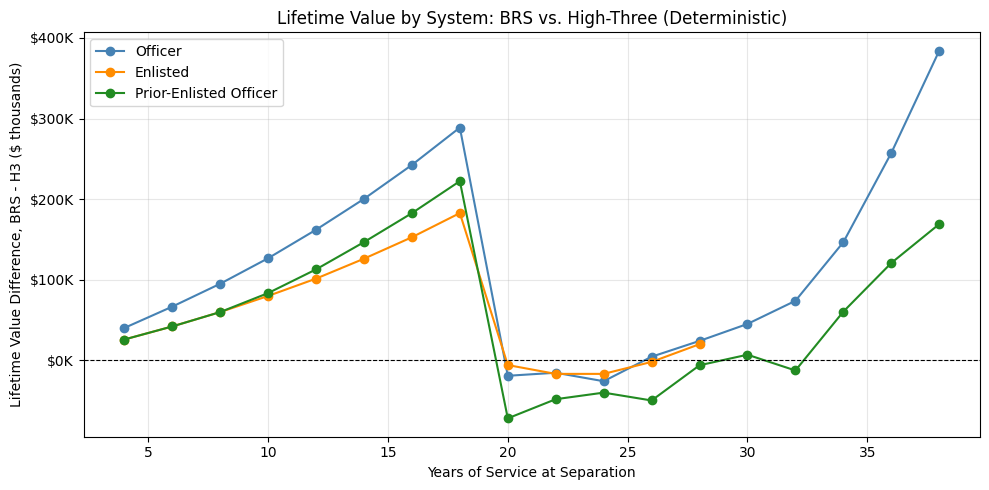

Key assumptions (deterministic baseline):
  COLA rate:          2.75%  (DoD Board of Actuaries long-term)
  Discount rate:      5.00%  (nominal NPV)
  TSP, BRS total:    10.00%  (member 5% + govt 5%)
  TSP, H3 total:      5.00%  (member 5% only)
  TSP returns:        glide-path L Fund historical means
  Life expectancy:    SSA 2022, male expected total age


In [11]:
profile_styles = {
    "Officer": ("steelblue", "Officer"),
    "Enlisted": ("darkorange", "Enlisted"),
    "PriorEnlistedOfficer": (
        "forestgreen", "Prior-Enlisted Officer"
    ),
}

fig, ax = plt.subplots(figsize=(10, 5))

for profile, (color, label) in profile_styles.items():
    sub = results[results["Profile"] == profile]
    ax.plot(
        sub["SepYOS"],
        sub["BRSAdv"] / 1000,
        marker="o",
        label=label,
        color=color,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Years of Service at Separation")
ax.set_ylabel(
    "Lifetime Value Difference, BRS - H3 ($ thousands)"
)
ax.set_title(
    "Lifetime Value by System: BRS vs. High-Three"
    " (Deterministic)"
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}K")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key assumptions (deterministic baseline):")
print(
    f"  COLA rate:          {COLA_RATE:.2%}"
    "  (DoD Board of Actuaries long-term)"
)
print(
    f"  Discount rate:      {DISCOUNT_RATE:.2%}"
    "  (nominal NPV)"
)
print(
    f"  TSP, BRS total:    {BRS_CONTRIB_RATE:.2%}"
    "  (member 5% + govt 5%)"
)
print(
    f"  TSP, H3 total:      {H3_MEMBER_RATE:.2%}"
    "  (member 5% only)"
)
print(
    "  TSP returns:        glide-path L Fund"
    " historical means"
)
print(
    "  Life expectancy:    SSA 2022, male"
    " expected total age"
)

## Save

In [12]:
out = PROCESSED / "deterministic_results.csv"
results.to_csv(out, index=False)
print(f"Saved: {out.name}  ({out.stat().st_size/1024:.1f} KB)")

Saved: deterministic_results.csv  (7.5 KB)
